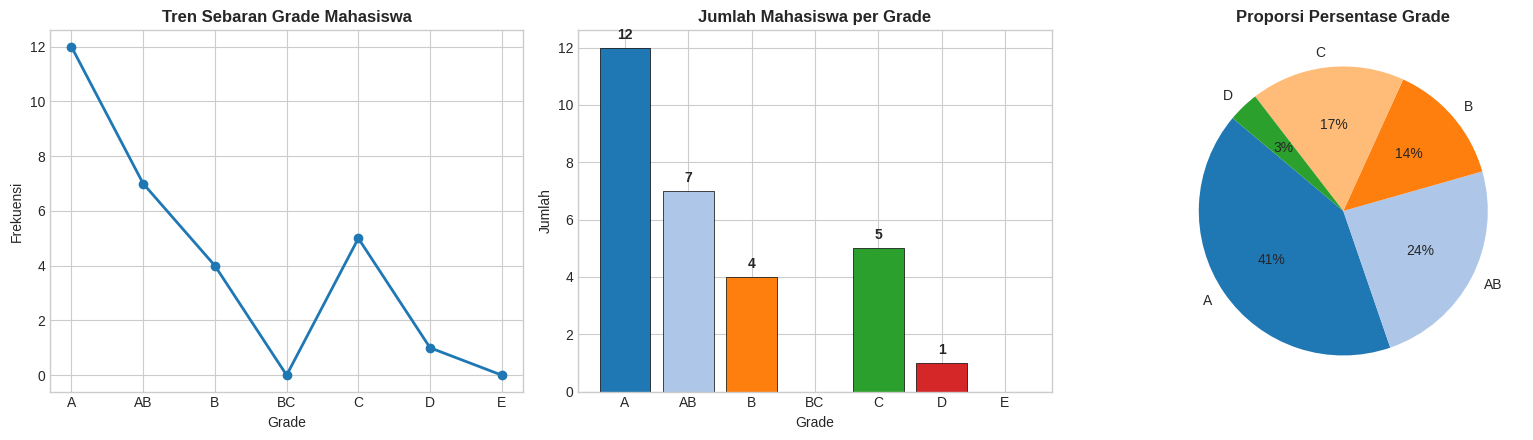


=== HASIL STATISTIKA DESKRIPTIF ===
count              29.000000
mean               76.675517
std                13.469082
min                46.010000
25%                70.210000
50%                79.300000
75%                87.290000
max                94.030000
Standard Error      2.501146
Median             79.300000
Mode               77.300000
Variance          181.416161
Range              48.020000
Skewness           -0.762053
Kurtosis           -0.351078
Name: Final_Score, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "sample_data/Ilham.xlsx"
df_raw = pd.read_excel(file_path)

df_students = df_raw.iloc[5:35, 1:8].copy()
df_students.columns = ['ID', 'Name', 'Kuis', 'UTS', 'UAS', 'Final_Score', 'Grade']
df_students['Final_Score'] = pd.to_numeric(df_students['Final_Score'], errors='coerce')

grade_order = ['A', 'AB', 'B', 'BC', 'C', 'D', 'E']
freq_table = df_students['Grade'].value_counts().reindex(grade_order, fill_value=0).reset_index()
freq_table.columns = ['Grade', 'Frekuensi']

plt.style.use('seaborn-v0_8-whitegrid')
colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', '#2ca02c', '#d62728', '#9467bd']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(freq_table['Grade'], freq_table['Frekuensi'], marker='o', color='#1f77b4', linewidth=2)
axes[0].set_title('Tren Sebaran Grade Mahasiswa', fontweight='bold')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Frekuensi')

bars = axes[1].bar(freq_table['Grade'], freq_table['Frekuensi'], color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Jumlah Mahasiswa per Grade', fontweight='bold')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Jumlah')
for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, yval + 0.2, int(yval), ha='center', va='bottom', fontweight='bold')

freq_pie = freq_table[freq_table['Frekuensi'] > 0]
axes[2].pie(freq_pie['Frekuensi'], labels=freq_pie['Grade'], autopct='%1.0f%%', startangle=140, colors=colors[:len(freq_pie)])
axes[2].set_title('Proporsi Persentase Grade', fontweight='bold')

plt.tight_layout()
plt.show()

scores = df_students['Final_Score']
stats = scores.describe()
stats['Standard Error'] = scores.sem()
stats['Median'] = scores.median()
stats['Mode'] = scores.mode().iloc[0]
stats['Variance'] = scores.var()
stats['Range'] = scores.max() - scores.min()
stats['Skewness'] = scores.skew()
stats['Kurtosis'] = scores.kurtosis()

print("\n=== HASIL STATISTIKA DESKRIPTIF ===")
print(stats)